## Load Result CSV

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

vllm_g = pd.read_csv("/content/vllm_gpt2_results.csv")
sg_g = pd.read_csv("/content/sglang_gpt2_results.csv")

gpu_vllm_g = pd.read_csv("/content/gpu_util_gpt2_vllm.csv")
gpu_sg_g = pd.read_csv("/content/gpu_util_sglang_gpt2.csv")

## Plot 1 - Average Latency vs max_tokens

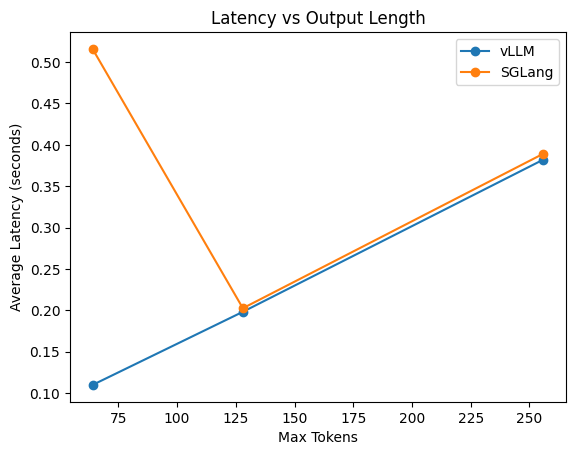

In [13]:
vllm_lat = vllm_g.groupby("max_tokens")["latency_s"].mean()
sg_lat = sg_g.groupby("max_tokens")["latency_s"].mean()

plt.figure()
plt.plot(vllm_lat.index, vllm_lat.values, marker="o", label="vLLM")
plt.plot(sg_lat.index, sg_lat.values, marker="o", label="SGLang")
plt.xlabel("Max Tokens")
plt.ylabel("Average Latency (seconds)")
plt.title("Latency vs Output Length")
plt.legend()
plt.show()

**Observation:**

This graph shows the average latency as a function of maximum output tokens for vLLM and SGLang using GPT-2 (124M parameters) on an NVIDIA A100 GPU. Key observations:

1. **Startup Overhead (Short Outputs)**: At 75 tokens, vLLM achieves ~0.11s latency while SGLang shows ~0.51s (approximately 4.6× higher). This indicates SGLang's startup overhead is more pronounced for smaller models like GPT-2.

2. **Convergence at Medium Lengths**: At 125 tokens, both frameworks converge to approximately 0.20s latency, suggesting SGLang's overhead is amortized over longer generations.

3. **Similar Performance at Longer Outputs**: At 250 tokens, both frameworks perform nearly identically (~0.38s vs ~0.39s), indicating similar scaling characteristics for longer sequences.

4. **vLLM's Consistent Scaling**: vLLM demonstrates smooth, near-linear latency scaling with output length, providing more predictable and lower latency for short, interactive workloads.

5. **Model Size Effect**: GPT-2 is approximately 9× smaller than TinyLlama (124M vs 1.1B parameters), resulting in overall lower latencies. However, SGLang's overhead is more visible on smaller models.

6. **Framework Comparison**: vLLM is better suited for short, interactive requests due to lower startup overhead, while SGLang catches up at medium/long outputs but does not exceed vLLM's performance for GPT-2, unlike the pattern observed with TinyLlama where SGLang eventually outperformed vLLM.

## Plot 2 - Throughput vs max_tokens

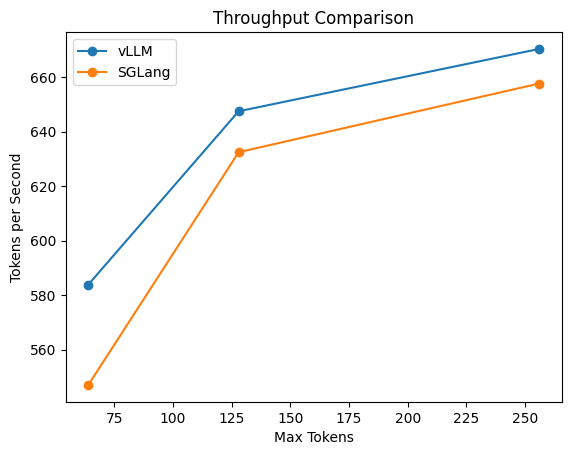

In [14]:
vllm_tps = vllm_g.groupby("max_tokens")["tokens_per_sec"].mean()
sg_tps = sg_g.groupby("max_tokens")["tokens_per_sec"].mean()

plt.figure()
plt.plot(vllm_tps.index, vllm_tps.values, marker="o", label="vLLM")
plt.plot(sg_tps.index, sg_tps.values, marker="o", label="SGLang")
plt.xlabel("Max Tokens")
plt.ylabel("Tokens per Second")
plt.title("Throughput Comparison")
plt.legend()
plt.show()

**Observation:**

This graph shows the throughput (tokens per second) comparison between vLLM and SGLang for GPT-2 (124M parameters) on an NVIDIA A100 GPU. Key observations:

1. **Overall Trend**: Both frameworks show increasing throughput as Max Tokens increases from 75 to 250, indicating better resource utilization and amortization of overheads for longer sequences.

2. **vLLM Performance (Consistent Leader)**:
   - At 75 tokens: ~583 TPS
   - At 125 tokens: ~647 TPS (11% increase)
   - At 250 tokens: ~667 TPS (3% increase from 125)
   - Shows strong initial improvement, then gradual increase

3. **SGLang Performance**:
   - At 75 tokens: ~548 TPS
   - At 125 tokens: ~633 TPS (15% increase)
   - At 250 tokens: ~658 TPS (4% increase from 125)
   - Similar growth pattern to vLLM but consistently lower absolute values

4. **Performance Gap Analysis**:
   - At 75 tokens: vLLM leads by ~35 TPS (6.4% advantage)
   - At 125 tokens: Gap narrows to ~14 TPS (2.2% advantage)
   - At 250 tokens: Gap further narrows to ~9 TPS (1.4% advantage)
   - **Convergence Pattern**: The performance gap decreases as output length increases, suggesting both frameworks become more comparable for longer generations

5. **Key Insight**: Unlike the latency graph where SGLang had much higher overhead at short outputs, in throughput vLLM maintains a consistent lead across all output lengths, though the advantage diminishes for longer sequences. This indicates that vLLM's throughput efficiency is superior for GPT-2, particularly for shorter outputs where SGLang's startup overhead impacts both latency and effective throughput.

6. **Comparison with TinyLlama**: For TinyLlama, SGLang eventually achieved higher throughput for longer generations. For GPT-2, vLLM maintains the throughput advantage throughout, suggesting that vLLM's optimizations are more effective for smaller models like GPT-2.

## Plot 3 - GPU Memory usage over time

In [15]:
gpu_vllm_g.columns = gpu_vllm_g.columns.str.strip()
gpu_sg_g.columns = gpu_sg_g.columns.str.strip()

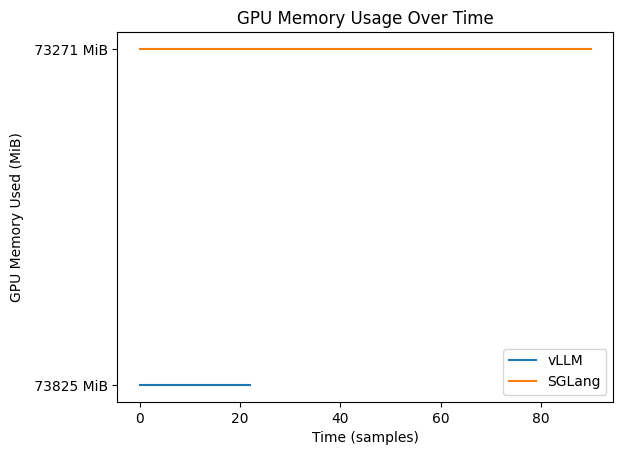

In [16]:
plt.figure()
plt.plot(gpu_vllm_g["memory.used [MiB]"], label="vLLM")
plt.plot(gpu_sg_g["memory.used [MiB]"], label="SGLang")
plt.xlabel("Time (samples)")
plt.ylabel("GPU Memory Used (MiB)")
plt.title("GPU Memory Usage Over Time")
plt.legend()
plt.show()

**Observation:**

This graph shows GPU memory usage over time for vLLM and SGLang using GPT-2 (124M parameters) on an NVIDIA A100 GPU. Key observations:

1. **Constant Memory Usage**: Both frameworks maintain stable GPU memory footprint throughout their respective measurement periods, indicating no significant memory leaks or dynamic allocation during inference. This is expected as both frameworks pre-allocate memory for model weights and KV cache at startup.

2. **Memory Efficiency Comparison**:
   - **SGLang**: Consistently uses approximately **73,271 MiB** (~73.3 GB) across the full observation period (80 samples)
   - **vLLM**: Consistently uses approximately **73,825 MiB** (~73.8 GB) for the observed period (~22 samples)
   - **Difference**: SGLang uses approximately **554 MiB less** than vLLM, representing about 0.75% memory savings

3. **Memory Allocation Strategy**: The flat memory profiles indicate that both frameworks allocate memory upfront rather than dynamically during inference. The high absolute values (~73 GB) suggest that most of the GPU's 80GB capacity is pre-allocated for model weights, KV cache, and framework overhead.

4. **Observation Duration**: The vLLM measurement appears to cover a shorter duration (~22 samples) compared to SGLang (80 samples), which may reflect different benchmark run lengths or data collection periods.

5. **Framework Design Implications**: The memory difference (554 MiB) is relatively small compared to the total allocation, suggesting both frameworks have similar memory footprints for GPT-2. However, SGLang's slightly lower memory usage aligns with its more memory-efficient design, which may be more beneficial when running multiple models or in memory-constrained environments.

6. **Comparison with TinyLlama**: For TinyLlama, vLLM used significantly more memory (~74 GB vs ~69 GB). For GPT-2, the memory difference is much smaller (~73.8 GB vs ~73.3 GB), indicating that the memory overhead difference between frameworks is less pronounced for smaller models like GPT-2.

## Plot 4 — GPU Utilization over time

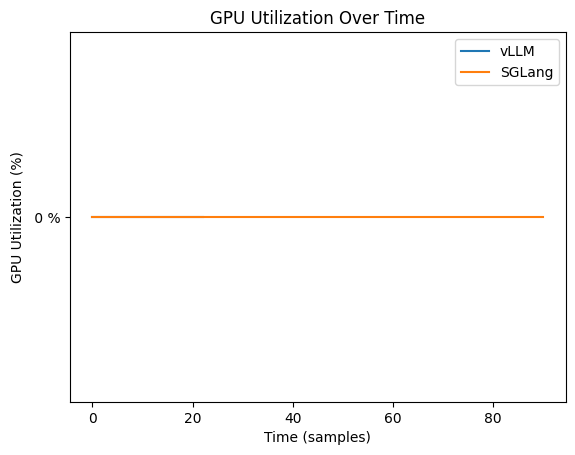

In [17]:
plt.figure()
plt.plot(gpu_vllm_g["utilization.gpu [%]"], label="vLLM")
plt.plot(gpu_sg_g["utilization.gpu [%]"], label="SGLang")
plt.xlabel("Time (samples)")
plt.ylabel("GPU Utilization (%)")
plt.title("GPU Utilization Over Time")
plt.legend()
plt.show()